In [1]:


import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from confidence.unsupervised.classic.SHE import SHETorchConfidence
from confidence.unsupervised.classic.dice import DICEConfidence
from confidence.unsupervised.classic.lof import LOFTorchConfidence
from model.classifier import Classifier, MyProgressBar
from utils.transforms.apply import grid_resample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
#get name of notebook this kernel runs
notebook_name = os.path.basename(globals()['__session__'])  # Get the name without extension
#remove the extension
notebook_name = os.path.splitext(notebook_name)[0]

In [5]:
from its.transform import multi_transform
from utils.affine_transforms import AffineTransformation2D
from dataset.mnist_no_pil import NoPILMNIST, NoPILFashionMNIST, AffineTransformDataset, NoPILEMNIST

dataset = 'emnist' # or 'fmnist'
batch_size = 128
#divide by 255 transform


if dataset == 'emnist':
    # essentially excluding either 6 or 9 as these would cause degenerations under 180 degree rotation
    dataset_train = NoPILEMNIST(experiment_files_path_data)
    n_classes = len(dataset_train.classes)
    dataset_val_test = NoPILEMNIST(experiment_files_path_data,train=False)
    #split into validation and test set
    dataset_val, dataset_test_pre = torch.utils.data.random_split(dataset_val_test,[0.5,0.5])


transformations = [AffineTransformation2D.ROTATION.value,AffineTransformation2D.SHEARING_X.value,AffineTransformation2D.SHEARING_Y.value
                     ,AffineTransformation2D.SCALING_X.value,AffineTransformation2D.SCALING_Y.value]
domains = [(-torch.pi,torch.pi), ((-0.5, 0.5),), ((-0.5, 0.5),), ((1/1.3-1, 0.3),), ((1/1.3-1, 0.3),)]
n_samples = 17


#test simulated annealing
from utils.transformation_problem import TransformationProblem
from utils.transform_sequence import TransformSequence, create_parameter_sampler, create_sampler

transform_seq= TransformSequence(transformations, domains, neighbour_hood_size =0.25,application_method=grid_resample,device="cpu",reflect=True,use_individual_param_correction=False)



sampler = create_sampler(transform_seq)

dataset_test = AffineTransformDataset(dataset_test_pre,sampler,return_transformation=False,batch_size=batch_size)

transform_seq.to(device)


In [6]:
dataset_test[0]

(tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           5.7270e-04, 1.1364e-02, 2.4747e-03, 2.9626e-03, 7.2368e-03,
           0.0000e+00, 6.2219e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 3.4464e-03, 3.7179e-03, 1.0458e-02,
           7.6608e-02, 1.3987e-01, 9.8962e-02, 1.3428e-01, 9.0922e-02,
           7.2500e-02, 1.1947e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
           0.0000e+00, 1.8967e-02, 6.4711e-02, 1.658

In [7]:
dataset_train_transformed = AffineTransformDataset(dataset_train,sampler,return_transformation=False,batch_size=batch_size)


In [8]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True)

In [9]:
train_loader_transformed = torch.utils.data.DataLoader(dataset_train_transformed, batch_size=batch_size, shuffle=True, num_workers=4,persistent_workers=True)

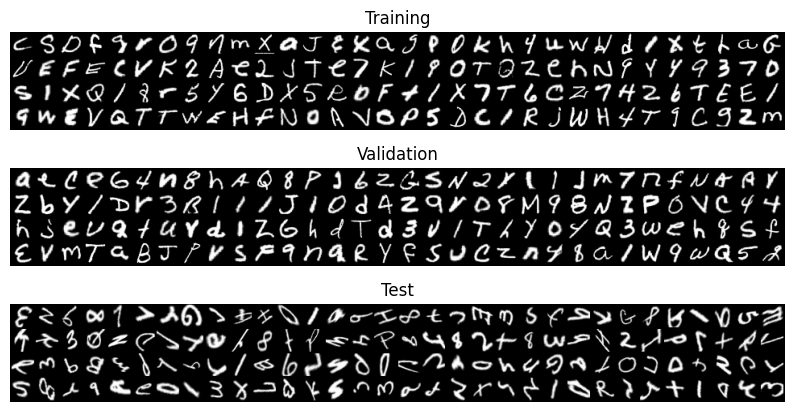

In [10]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')

for ax in axs.flat:
    ax.axis('off')

In [11]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=10,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric.pth


In [12]:
#calibrate the model
#from confidence.calibration import TemperatureCalibrationModule
#if model is not temperature calibrated
#if isinstance(model, TemperatureCalibrationModule):
    #model = model.model
#model = TemperatureCalibrationModule(model,per_logit=True).cuda()
#model.fit(test_loader)


In [13]:
model.cuda().eval()

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [14]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in val_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_val)
    print(f'Mean accuracy on the val set: {test_acc}.')

Mean accuracy on the val set: 0.8789361702127659.


In [15]:
with torch.no_grad():
    model.eval()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

Mean accuracy on the transformed test set: 0.20755319148936172.


In [16]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric3.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(128),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(256),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),  # Output: 256x7x7
    nn.BatchNorm2d(256),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x4x4
    nn.Flatten(),
    nn.Linear(256 * 3 * 3, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model2, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader_transformed, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model2.state_dict(), model_path)
    print(f"Model saved to {model_path}")


with torch.no_grad():
    model2.eval().cuda()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')

model2= None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric3.pth
Mean accuracy on the transformed test set: 0.6859574468085107.


In [17]:
modelpath = os.path.join(os.getcwd(), "model", f"{dataset}_metric2.pth")
import pytorch_lightning as pl
import os

model_path = modelpath

model2 = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    torch.nn.Dropout(0.5),  # Dropout layer with 50% dropout rate
    nn.GELU(),
    nn.Linear(128, n_classes)
)

# Check if model is already trained
if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    model2.load_state_dict(torch.load(model_path))
else:
    print(f"Training model and will save to {model_path}")
    lightning_model = Classifier(model2, optimizer_class=torch.optim.AdamW, optimizer_params={"lr": 1e-3})
    progress_bar = MyProgressBar()
    trainer = pl.Trainer(
        accelerator="cuda",
        max_epochs=30,
        precision="16-mixed",
        callbacks=[progress_bar],
    )
    # Train the model
    trainer.fit(lightning_model, train_loader_transformed, val_loader)
    # Test the model
    #trainer.test(lightning_model, test_loader)
    # Save model
    torch.save(model2.state_dict(), model_path)
    print(f"Model saved to {model_path}")


with torch.no_grad():
    model2.eval().cuda()
    test_acc = 0
    for data, target in test_loader:
        data, target = data.cuda(), target.cuda()
        output = model2(data)
        test_acc += output.argmax(dim=-1).eq(target).sum().item()
    test_acc /= len(dataset_test)
    print(f'Mean accuracy on the transformed test set: {test_acc}.')


model2= None
torch.cuda.empty_cache()

Loading model from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_notebooks\comparision_metrics\model\emnist_metric2.pth
Mean accuracy on the transformed test set: 0.6302127659574468.


In [18]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [19]:
from confidence.utils import ModelInputWrapper

#use model wrapper to extract the embeddings
dual_ouput_model = ModelInputWrapper(model,'10',flatten=True).eval()

In [20]:
filter_correct = True  # Set to False to include all samples

embeddings = []
images = []
classes = []
logits = []

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch, logit_batch = dual_ouput_model(data_cuda)
    pred_batch = logit_batch.argmax(dim=-1).cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = pred_batch == target_np
        emb_np = emb_batch.detach().cpu().numpy()[mask]
        logit_np = logit_batch.detach().cpu().numpy()[mask]
        img_np = data.numpy()[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        logit_np = logit_batch.detach().cpu().numpy()
        img_np = data.numpy()
        class_np = target_np

    embeddings.append(emb_np)
    logits.append(logit_np)
    images.append(img_np)
    classes.append(class_np)

embeddings = np.vstack(embeddings)
logits     = np.vstack(logits)
images     = np.vstack(images)
classes    = np.hstack(classes)

# randomly sample 5000 entries
if embeddings.shape[0] > 5000:
    indices = np.random.choice(embeddings.shape[0], 5000, replace=False)
    embeddings_sampled = embeddings[indices]
    logits_sampled     = logits[indices]
    images_sampled     = images[indices]
    classes_sampled    = classes[indices]
else:
    embeddings_sampled = embeddings
    logits_sampled     = logits
    images_sampled     = images
    classes_sampled    = classes

In [21]:

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence

In [22]:
import search.shgo
import importlib

importlib.reload(search.shgo)
di = search.shgo.SHGO(selection_method="topk")
di_no_grad = search.shgo.SHGO(selection_method="topk", local_max_steps=0)

In [23]:
dual_ouput_model_input = ModelInputWrapper(model,'0',flatten=False).eval()

In [24]:
def evaluate_conf(model, di, problem, test_loader, max_batch_override=None):
    if max_batch_override is not None:
        problem.max_batch_size = max_batch_override
    with torch.no_grad():
        test_acc_sim = 0
        counter = 0
        for data, target in tqdm.tqdm(test_loader):
            data, target = data.cuda(), target.cuda()
            with torch.enable_grad():
                res = di.optimize(problem, data.cuda(), y=target.cuda())
                res = list(res)
            torch.cuda.empty_cache()
            res[0] = res[0].detach()  # Detach the result to avoid gradients
            res[1] = res[1].detach()  # Detach the result to avoid gradients
            # Apply the transformation and get predictions
            x_transformed2 = problem.transform(data.cuda(), res[0])
            logits = model(x_transformed2)
            output = logits.argmax(dim=-1)
            test_acc_sim += output.eq(target).sum().cpu().detach().item()
            counter += output.shape[0]

    test_acc_sim /= counter
    return test_acc_sim


import tqdm

from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence

conf_mod_nn_pytorch = SinglePassConfidence(model, EnergyConfidence())
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch, transform_seq, consolidate_method="consolidate_simple")
evaluate_conf(model, di, problem_nn_pytorch, test_loader)

100%|██████████| 74/74 [00:15<00:00,  4.81it/s]


0.5891489361702128

In [25]:
from confidence.supervised.ml.energy import EnergyPredictionConfidence
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)



encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 1)
).cuda()


sampling_strategy = TransformLatentSamplingStrategy(transform_seq,model[:10])
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = EnergyPredictionConfidence(encoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},negative_sampling_module=sm,loss_type="mse").cuda()


gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "cosine"
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA GeForce RTX 4070') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
-----------------------------------------------------------

Epoch 9: 100%|██████████| 793/793 [00:08<00:00, 95.43it/s, v_num=397, train_loss_step=0.0305, train_loss_epoch=0.037]  

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 793/793 [00:08<00:00, 95.25it/s, v_num=397, train_loss_step=0.0305, train_loss_epoch=0.037]


KeyboardInterrupt: 

In [26]:
from confidence.supervised.ml.energy import EnergyPredictionConfidence
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)



encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 1)
).cuda()


sampling_strategy = TransformLatentSamplingStrategy(transform_seq,model[:10])
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = EnergyPredictionConfidence(encoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},negative_sampling_module=sm,loss_type="triplet").cuda()


gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "cosine"
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | train
1 | feature_extractor        | Sequential           | 420 K  | eval 
2 | energy_model             | Sequential           | 131 K  | train
--------------------------------------------------------------------------
131 K     Trainable params
420 K     Non-trainable params
552 K     Total params
2.210     Total estimated model params size (MB)
7         Modules in train mode
11        Modules in eval mode


Epoch 9: 100%|██████████| 793/793 [00:07<00:00, 106.54it/s, v_num=370, train_loss_step=0.0302, train_loss_epoch=0.0974]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 793/793 [00:07<00:00, 106.37it/s, v_num=370, train_loss_step=0.0302, train_loss_epoch=0.0974]
Mean accuracy on the transformed test set with GD: 0.5311702127659574.


In [27]:
gmm_conf.cuda()
gmm_conf.map_func=lambda x: -x
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.05585106382978723.


In [28]:
data,target = next(iter(test_loader))
embed=model[:10](data.cuda())

In [29]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [30]:
gmm_conf(embed)

tensor([-9.6338e+00,  6.6442e+00,  1.0427e+01, -6.7089e+00, -6.2636e+00,
        -7.2741e+00, -7.5131e+00, -4.7885e+00, -4.5047e+00, -6.5565e+00,
        -4.0469e+00, -5.3935e+00, -6.9327e-01, -2.2135e+00,  1.0667e+01,
         5.2272e+00, -6.6880e+00, -4.5736e+00,  4.1161e+00, -8.0795e+00,
        -8.9438e+00, -6.1154e+00,  1.1954e+00, -7.6854e+00, -1.5468e-01,
        -5.6958e+00, -9.6600e+00,  1.5203e+01,  1.0638e+01, -4.7049e+00,
        -3.7410e+00,  9.9599e+00, -6.6509e+00,  1.9842e+00,  8.9645e+00,
        -9.0184e+00, -9.4610e+00, -2.8172e+00, -7.5078e+00, -4.0695e+00,
        -7.3399e+00, -7.8066e+00,  4.4724e+00, -9.1386e+00, -3.8184e+00,
         6.3722e+00, -4.7119e+00,  5.9078e+00, -6.5888e+00,  1.9290e+00,
         4.5181e-01, -4.1549e+00, -2.2093e+00, -5.7347e+00,  2.3511e-01,
        -7.7648e+00, -2.5204e+00, -6.7637e+00, -1.6124e+00, -8.3251e+00,
         6.6200e+00, -7.5145e+00, -6.0115e+00, -7.0686e+00, -5.0303e+00,
         8.0607e+00, -6.6984e+00, -7.4883e+00, -2.4

In [31]:
from confidence.supervised.ml.energy import EnergyPredictionConfidence
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)



encoder_lin = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 256),
)

decoder_lin =nn.Sequential(
    nn.Linear(256, 64 * 7 * 7),
    nn.GELU(),
    nn.Unflatten(1, (64, 7, 7)),
    nn.ConvTranspose2d(64, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x7x7
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.Upsample(scale_factor=2),  # Output: 32x14x14
    nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),  # Output: 1x14x14
    nn.BatchNorm2d(1),  # Batch Normalization
    nn.GELU(),
    nn.Upsample(scale_factor=2),  # Output: 1x28x28
    nn.ConvTranspose2d(1, 1, kernel_size=3, stride=1, padding=1)  # Output: 1x28x28
)



sampling_strategy = TransformLatentSamplingStrategy(transform_seq,nn.Identity())
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = confidence.supervised.ml.contrastive_autoencoder.ContrastiveAutoencoder(encoder_lin,decoder_lin,margin=10,trainer_kwargs={"max_epochs": 7},dataloader_kwargs={"batch_size": 64},negative_sampling_module=sm).cuda()

gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model_input, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:209: Attribute 'negative_sampling_module' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['negative_sampling_module'])`.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:45: Attribute 'negative_sampling_module' removed from hparams because it cannot be pickled. You can suppress this warning by setting `self.save_hyperparameters(ignore=['negative_sampling_module'])`.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | P

Epoch 6: 100%|██████████| 1586/1586 [00:12<00:00, 123.90it/s, v_num=371, train_loss_step=0.0648, train_loss_epoch=0.215]

`Trainer.fit` stopped: `max_epochs=7` reached.


Epoch 6: 100%|██████████| 1586/1586 [00:12<00:00, 123.30it/s, v_num=371, train_loss_step=0.0648, train_loss_epoch=0.215]
Mean accuracy on the transformed test set with GD: 0.2642553191489362.


In [32]:
from confidence.supervised.ml.energy import EnergyPredictionConfidence
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)



encoder_lin = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Output: 32x28x28
    nn.BatchNorm2d(32),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 32x14x14
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # Output: 64x14x14
    nn.BatchNorm2d(64),  # Batch Normalization
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2),  # Output: 64x7x7
    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.GELU(),
    nn.Linear(128, 1)
)

sampling_strategy = TransformLatentSamplingStrategy(transform_seq,nn.Identity())
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = EnergyPredictionConfidence(encoder_lin,trainer_kwargs={"max_epochs": 20},dataloader_kwargs={"batch_size": 128},negative_sampling_module=sm).cuda()

gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "cosine"
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model_input, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | train
1 | feature_extractor        | Identity             | 0      | eval 
2 | energy_model             | Sequential           | 420 K  | train
--------------------------------------------------------------------------
420 K     Trainable params
0         Non-trainable params
420 K     Total params
1.683     Total estimated model params size (MB)
14        Modules in train mode
1         Modules in eval mode


Epoch 19: 100%|██████████| 793/793 [00:06<00:00, 117.34it/s, v_num=372, train_loss_step=0.0149, train_loss_epoch=0.0124] 

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 793/793 [00:06<00:00, 117.04it/s, v_num=372, train_loss_step=0.0149, train_loss_epoch=0.0124]
Mean accuracy on the transformed test set with GD: 0.3295744680851064.


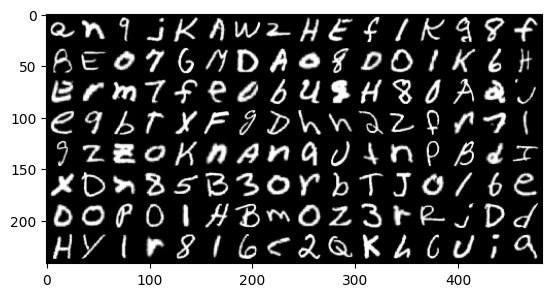

In [33]:
#make data an imagegrid
data, target = next(iter(train_loader))

grid = torchvision.utils.make_grid(data, nrow=16).permute(1, 2, 0).cpu()
plt.imshow(grid)

In [34]:
gmm_conf(data.cuda())

tensor([0.7126, 0.4826, 0.6175, 0.5967, 0.4061, 0.5811, 0.6741, 0.5743, 0.8135,
        0.7370, 0.7372, 0.4577, 0.6944, 0.7330, 0.5856, 0.6281, 0.6441, 0.6613,
        0.7189, 0.5778, 0.7041, 0.3743, 0.4935, 0.6691, 0.7112, 0.7884, 0.7065,
        0.7088, 0.6092, 0.8645, 0.6939, 0.6528, 0.8299, 0.8863, 0.5284, 0.7767,
        0.4972, 0.7956, 0.7559, 0.7227, 0.6163, 0.5972, 0.8637, 0.5615, 0.4473,
        0.7698, 0.3946, 0.6172, 0.7726, 0.6160, 0.8090, 0.4747, 0.5103, 0.7115,
        0.7473, 0.7844, 0.6649, 0.1336, 0.6092, 0.6955, 0.8132, 0.6052, 0.5117,
        0.3911, 0.7151, 0.6025, 0.7118, 0.8493, 0.4203, 0.5175, 0.6578, 0.5605,
        0.4504, 0.8045, 0.3595, 0.5402, 0.7293, 0.7568, 0.5108, 0.7250, 0.4927,
        0.8051, 0.3006, 0.4096, 0.5790, 0.7730, 0.8994, 0.6169, 0.7780, 0.9572,
        0.7888, 0.6841, 0.8184, 0.5660, 0.5712, 0.5824, 0.8813, 0.5387, 0.5184,
        0.8656, 0.6550, 0.6359, 0.8946, 0.4056, 0.8740, 0.4845, 0.4622, 0.6680,
        0.4892, 0.5673, 0.6752, 0.6975, 

In [35]:
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)

from confidence.supervised.ml.contrastive_autoencoder import ContrastiveAutoencoder

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()

sampling_strategy = TransformLatentSamplingStrategy(transform_seq,model[:10])
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = ContrastiveAutoencoder(encoder_lin, decoder_lin,margin=10,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},distance_type="l2",mode="reconstruction",negative_sampling_module=sm).cuda()


gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "cosine"
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | train
1 | feature_extractor        | Sequential           | 420 K  | eval 
2 | encoder                  | Sequential           | 133 K  | train
3 | decoder                  | Sequential           | 133 K  | train
--------------------------------------------------------------------------
267 K     Trainable params
420 K     Non-trainable params
688 K     Total params
2.753     Total estimated model params size (MB)
13        Modules in train mode
11        Modules in eval mode


Epoch 9: 100%|██████████| 793/793 [00:06<00:00, 123.57it/s, v_num=373, train_loss_step=2.230, train_loss_epoch=2.140]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 793/793 [00:06<00:00, 123.24it/s, v_num=373, train_loss_step=2.230, train_loss_epoch=2.140]
Mean accuracy on the transformed test set with GD: 0.5746808510638298.


In [36]:
from confidence.supervised.ml.energy import EnergyPredictionConfidence
from utils.sampling import BatchNegativeSampler
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import confidence.supervised.ml.contrastive_autoencoder
import importlib

importlib.reload(confidence.supervised.ml.contrastive_autoencoder)
importlib.reload(confidence.unsupervised.unsupervised_base)



encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 1)
).cuda()


sampling_strategy = TransformLatentSamplingStrategy(transform_seq,model[:10])
sm =BatchNegativeSampler(sampling_strategy)

gmm_conf = EnergyPredictionConfidence(encoder_lin,trainer_kwargs={"max_epochs": 10},dataloader_kwargs={"batch_size": 128},negative_sampling_module=sm).cuda()


gmm_conf.fit(torch.tensor(images).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
gmm_conf.distance_type = "cosine"
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf2 = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf2, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name                     | Type                 | Params | Mode 
--------------------------------------------------------------------------
0 | negative_sampling_module | BatchNegativeSampler | 0      | train
1 | feature_extractor        | Sequential           | 420 K  | eval 
2 | energy_model             | Sequential           | 131 K  | train
--------------------------------------------------------------------------
131 K     Trainable params
420 K     Non-trainable params
552 K     Total params
2.210     Total estimated model params size (MB)
7         Modules in train mode
11        Modules in eval mode


Epoch 9: 100%|██████████| 793/793 [00:06<00:00, 117.12it/s, v_num=374, train_loss_step=0.0335, train_loss_epoch=0.0366]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 793/793 [00:06<00:00, 116.91it/s, v_num=374, train_loss_step=0.0335, train_loss_epoch=0.0366]
Mean accuracy on the transformed test set with GD: 0.5348936170212766.


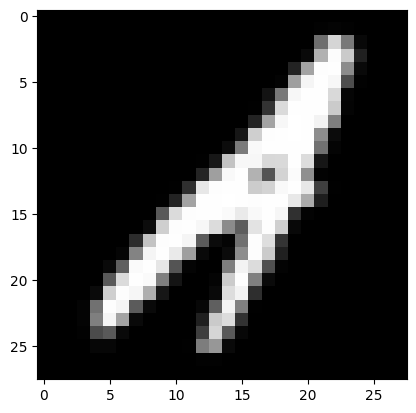

In [37]:
plt.imshow(images[0,0], cmap='gray')

In [84]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence
nn_pytorch = KNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu())
nn_pytorch.cuda()


conf_split = SplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5902127659574468.


In [85]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.0)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.601063829787234.


In [89]:


from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import PerClassKNNConfidence
nn_pytorch = PerClassKNNConfidence(metric="cosine",k=3)
nn_pytorch.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nn_pytorch.cuda()


conf_split = PredictedSplitConfidence(nn_pytorch,EnergyConfidence(), mult=False,b=0.01)
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.6251063829787235.


In [40]:


from confidence.direct.prob_based import EntropyConfidence
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence,NNGuideSplitConfidence


class one_confidence(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return torch.ones_like(x)[:,0]

class one_confidence2(nn.Module):
    def __init__(self):
        super().__init__()
        self.EnergyConfidence = EnergyConfidence()

    def forward(self, x,y=None):
        return self.EnergyConfidence(x,y)

conf_split = NNGuideSplitConfidence(one_confidence2(), k=3)
conf_split.fit((torch.tensor(embeddings_sampled).cpu(), torch.tensor(logits_sampled).cpu()))
conf_split.cuda()
conf_mod_nn_pytorch = SinglePassConfidence(dual_ouput_model,conf_split,index=1)
problem_nn_pytorch = TransformationProblem(conf_mod_nn_pytorch,transform_seq,consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5601063829787234.


In [41]:
nn_pytorch.save("test.pth")
nn_pytorch.load("test.pth")

In [42]:
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_nn_pytorch, data.cuda(),y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_nn_pytorch.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5668085106382978.


In [43]:
problem_nn_pytorch.calculate_error(data.cuda(), torch.zeros(data.shape[0],5).cuda())

(tensor([ -40.7839,  -46.9592,  -39.4550, -147.9802,  -47.4905,  -70.6258,
          -31.2234,  -62.3707,  -43.6151,  -59.2667,  -34.9496,  -50.0848,
          -32.8616,  -48.5592,  -51.5822,  -80.9884,  -71.2897,  -63.3417,
          -42.3703,  -38.1545,  -62.1627,  -72.2893,  -66.1940,  -32.6536,
          -62.1199,  -58.7910,  -59.2580,  -95.2123,  -87.8452,  -39.9717,
         -120.1483,  -14.5833,  -33.6556,  -49.1175, -110.2412,  -36.1884,
          -66.1362,  -27.9245,  -67.3298,  -61.7257,  -22.7618,  -19.7670,
          -70.0535,  -52.9509,  -21.3579, -139.3618,  -70.7827, -132.2194,
          -20.6280,  -41.8354,  -87.4619,  -36.8194,  -42.3113,  -49.7703,
          -40.2610,  -22.6764], device='cuda:0', grad_fn=<NegBackward0>),
 tensor([43, 34,  8, 14, 26, 25, 45, 46, 17, 34, 34,  2, 46, 46, 13, 37, 41, 30,
         44, 10, 24, 17, 26, 24, 34, 30, 33,  6, 33, 30, 14, 30, 35, 30,  3,  3,
          5, 19,  4,  3, 25, 36, 13, 15, 45, 28, 30,  3, 30,  2, 29, 26, 19, 36,
        

In [44]:
from confidence.unsupervised.classic.lle import LLEResidualConfidence

lle_conf = LLEResidualConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cpu())
lle_conf.cuda()
conf_split = SplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4723404255319149.


In [45]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf = OpenMaxConfidence()
lle_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())
lle_conf.cuda()
conf_split = PredictedSplitConfidence(lle_conf, EnergyConfidence(), mult=False, b=0.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.39659574468085107.


In [46]:
#extract logits from train
logits2 = []
classes2 = []
for batch in train_loader:
    logits_batch = model(batch[0].cuda())
    logits2.append(logits_batch.detach().cpu().numpy())
    classes2.append(batch[1].detach().cpu().numpy())
logits2 = np.vstack(logits2)
classes2 = np.hstack(classes2)

In [47]:
from confidence.unsupervised.classic.openmax import OpenMaxConfidence
from confidence.control.split import PredictedSplitConfidence

lle_conf2 = OpenMaxConfidence()
lle_conf2.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf2.cuda()
conf_split = PredictedSplitConfidence(lle_conf,lle_conf2, mult=False, a=0.0,b=1.0)
conf_mod_lle = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.46872340425531916.


In [48]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidenceNumpy as OpenMaxConfidence2
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence2()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
    break
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

  0%|          | 0/74 [00:11<?, ?it/s]

Mean accuracy on the transformed test set with GD: 0.5703125.


In [49]:
from confidence.unsupervised.classic.openmax3 import OpenMaxConfidence as OpenMaxConfidence3
from confidence.control.split import PredictedSplitConfidence
import tqdm
lle_conf3 = OpenMaxConfidence3()
lle_conf3.fit(torch.tensor(logits2).cuda(), y=torch.tensor(classes2).cuda())
lle_conf3.cuda()

conf_mod_lle = SinglePassConfidence(model, lle_conf3)
transformation_problem = TransformationProblem(conf_mod_lle, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di_no_grad.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]
test_acc_sim /= counter
print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

100%|██████████| 74/74 [00:04<00:00, 15.11it/s]

Mean accuracy on the transformed test set with GD: 0.555.


In [50]:
from confidence.unsupervised.classic.nn import NNDistanceConfidence

nearest_neighbor_confidence = NNDistanceConfidence(index_type="ivfpq", number_of_neighbors=3)
nearest_neighbor_confidence.fit(torch.tensor(embeddings_sampled).cpu(), y=torch.tensor(classes_sampled).cpu())
nearest_neighbor_confidence.cuda()
conf_split = SplitConfidence(nearest_neighbor_confidence, EnergyConfidence(), mult=False, b=0.0)
conf_mod = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
transformation_problem = TransformationProblem(conf_mod, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(transformation_problem, data.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = transformation_problem.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.40914893617021275.


In [51]:

from confidence.unsupervised.classic.gmm import GaussianMixtureConfidence

gmm_conf = GaussianMixtureConfidence(n_components=10, covariance_type="full")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.10_3.10.3056.0_x64__qbz5n2kfra8p0\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, 

Mean accuracy on the transformed test set with GD: 0.5604255319148936.


In [52]:

from confidence.unsupervised.classic.isolation import HardIsolationForestConfidence

gmm_conf = HardIsolationForestConfidence(contamination=0.01,max_features=10)
gmm_conf.fit(embeddings)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.2230851063829787.


In [53]:


from confidence.unsupervised.classic.trust_score import TrustScoreTorchConfidence

gmm_conf = TrustScoreTorchConfidence()
gmm_conf.device = "cuda"
gmm_conf.fit(torch.tensor(embeddings_sampled).cuda(),torch.tensor(classes_sampled).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=None)

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4726595744680851.


In [54]:


from confidence.unsupervised.classic.kde import KDEConfidence

gmm_conf = KDEConfidence(bandwidth=0.2, kernel="gaussian")
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4307446808510638.


In [55]:

from confidence.unsupervised.classic.osvm import OCSVMPredictiveConfidence

gmm_conf = OCSVMPredictiveConfidence(nu=0.01)
gmm_conf.fit(embeddings_sampled)
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.1851063829787234.


In [56]:
import confidence.unsupervised.classic.pca
import importlib

importlib.reload(confidence.unsupervised.classic.pca)
from confidence.unsupervised.classic.pca import PCATorchConfidence

gmm_conf = PCATorchConfidence(n_components=32)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.3515957446808511.


In [57]:




from confidence.unsupervised.classic.gaussian import ImageGaussianConfidence

gmm_conf = ImageGaussianConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4096808510638298.


In [58]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.95)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.34797872340425534.


In [59]:


from confidence.unsupervised.classic.dice import DICEConfidence


gmm_conf = DICEConfidence(model,percentile=0.01)
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.34808510638297874.


In [60]:






from confidence.unsupervised.classic.kl_matching import KLMatchingConfidence

gmm_conf = KLMatchingConfidence()
gmm_conf.fit(torch.tensor(logits2).cuda(),y=torch.tensor(classes2).cuda())
gmm_conf.cuda()
gmm_conf = SinglePassConfidence(model, gmm_conf)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 74/74 [00:37<00:00,  1.98it/s]

Mean accuracy on the transformed test set with GD: 0.43159574468085105.


In [61]:
gmm_conf = LOFTorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 74/74 [02:08<00:00,  1.73s/it]

Mean accuracy on the transformed test set with GD: 0.5843617021276596.


In [62]:
torch.cuda.empty_cache()

In [63]:
from confidence.unsupervised.classic.mahalanobis_relative import RelativeMahalanobisConfidence

gmm_conf = RelativeMahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 74/74 [00:10<00:00,  7.35it/s]

Mean accuracy on the transformed test set with GD: 0.535.


In [64]:
torch.cuda.empty_cache()

In [65]:
from confidence.unsupervised.classic.pyood_wrapper import MahalanobisConfidence

gmm_conf = MahalanobisConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 74/74 [00:23<00:00,  3.16it/s]

Mean accuracy on the transformed test set with GD: 0.5227659574468085.


In [66]:

from confidence.unsupervised.classic.mtc import ManifoldTangentConfidence

gmm_conf = ManifoldTangentConfidence(n_components=128,n_clusters=50)
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Unsupervised clustering: running k-means
fitted


100%|██████████| 74/74 [00:09<00:00,  7.40it/s]

Mean accuracy on the transformed test set with GD: 0.3824468085106383.


In [67]:

from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = SHETorchConfidence()
gmm_conf.fit(torch.tensor(embeddings).cuda(),y=torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

For correct functionality one must prefilter embeddings to only keep correctly classified ones.
fitted


100%|██████████| 74/74 [00:09<00:00,  7.91it/s]

Mean accuracy on the transformed test set with GD: 0.34585106382978725.


In [68]:
intermediate_output_model = model[:-3]

In [67]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
  (10): Dropout(p=0.5, inplace=False)
  (11): GELU(approximate='none')
  (12): Linear(in_features=128, out_features=47, bias=True)
)

In [84]:
filter_correct = True  # Set to False to include all samples
embeddings22 = []
images22 = []
classes22 = []
logits22 = []
from confidence.utils import ModelInputOutputWrapper
dual_ouput_model22 = ModelInputOutputWrapper(model,"12",capture_modes=["input"])

for data, target in train_loader:
    data_cuda = data.cuda()
    emb_batch,logits_batch = dual_ouput_model22(data_cuda)
    #emb_batch2 = model[:-1](data_cuda)
    #assert torch.allclose(emb_batch, emb_batch2), "Embeddings do not match between models."
    emb_batch = emb_batch.detach().cpu().numpy()
    target_np = target.numpy()

    if filter_correct:
        mask = target_np == logits_batch.argmax(dim=-1).cpu().numpy()
        emb_np = emb_batch[mask]
        class_np = target_np[mask]
    else:
        emb_np = emb_batch.detach().cpu().numpy()
        class_np = target_np

    embeddings22.append(emb_np)
    classes22.append(class_np)

embeddings22 = np.vstack(embeddings22)
classes22 = np.hstack(classes22)







from confidence.control.classify import ClassifyingConfidence
from confidence.unsupervised.classic.VIM import ViMTorchConfidence
gmm_conf = ViMTorchConfidence(model.eval(),n_dim=32,use_energy=True)
gmm_conf.fit(torch.tensor(embeddings22).cuda(),y=torch.tensor(classes22).cuda())
gmm_conf.cuda()

conf_split = ClassifyingConfidence(gmm_conf,index=1,index_confidence=0)
gmm_conf = SinglePassConfidence(dual_ouput_model22, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
print("fitted")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(tqdm.tqdm(test_loader)):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

fitted


100%|██████████| 74/74 [00:08<00:00,  8.24it/s]

Mean accuracy on the transformed test set with GD: 0.5720212765957446.


In [ ]:
gjhkkjhg

In [70]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import BasicAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
decoder_lin = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = BasicAutoencoderConfidence(encoder_lin, decoder_lin,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
267 K     Trainable params
0         Non-trainable params
267 K     Total params
1.071     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages

Epoch 4: 100%|██████████| 793/793 [00:10<00:00, 73.80it/s, v_num=375, train_loss=0.954]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 793/793 [00:10<00:00, 73.56it/s, v_num=375, train_loss=0.954]
Mean accuracy on the transformed test set with GD: 0.5111702127659574.


In [71]:
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)
from confidence.unsupervised.ml.autoencoder import ConditionalAutoencoderConfidence

encoder_lin = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
    nn.Linear(128, 16)
).cuda()
n_classes = len(np.unique(classes))

decoder_lin = torch.nn.Sequential(
    nn.Linear(16 + n_classes, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = ConditionalAutoencoderConfidence(encoder_lin, decoder_lin,num_classes=n_classes,trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda(),torch.tensor(classes).cuda())
gmm_conf.cuda()
conf_split = PredictedSplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 133 K  | train
1 | decoder | Sequential | 139 K  | train
-----------------------------------------------
273 K     Trainable params
0         Non-trainable params
273 K     Total params
1.095     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 793/793 [00:04<00:00, 173.06it/s, v_num=376, train_loss=0.929]

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 793/793 [00:04<00:00, 172.49it/s, v_num=376, train_loss=0.929]
Mean accuracy on the transformed test set with GD: 0.5261702127659574.


In [72]:


from confidence.unsupervised.ml.deepsvd import DeepSVDDConfidence

encoder_lin_deep = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 128,bias=False),
    nn.LeakyReLU(),
    nn.Linear(128, 16,bias=False)
).cuda()
gmm_conf = DeepSVDDConfidence(encoder_lin_deep,objective="one-class",trainer_kwargs={"max_epochs": 5},dataloader_kwargs={"batch_size": 128},weight_decay=0.001)
gmm_conf.cuda()
gmm_conf.fit(torch.tensor(embeddings).cuda()).cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")

test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

bias terms are not recommended for DeepSVDD, this is not checked here. Similary unbounded activations are prefered and weight decay/reg to avoid trivial solutions.


You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | Sequential | 34.8 K | train
-----------------------------------------------
34.8 K    Trainable params
0         Non-trainable params
34.8 K    Total params
0.139     Total estimated model params size (MB)
6         Modules in train mode
0         Modules in eval mode


Epoch 4: 100%|██████████| 793/793 [00:03<00:00, 229.05it/s, v_num=377, train_loss=0.014]  

`Trainer.fit` stopped: `max_epochs=5` reached.


Epoch 4: 100%|██████████| 793/793 [00:03<00:00, 228.66it/s, v_num=377, train_loss=0.014]
Mean accuracy on the transformed test set with GD: 0.2679787234042553.


In [73]:
from confidence.unsupervised.ml.vae import VAEConfidence
import confidence.unsupervised.ml.autoencoder
import importlib

importlib.reload(confidence.unsupervised.ml.autoencoder)


encoder_lin2 = torch.nn.Sequential(
    nn.Linear(embeddings.shape[1], 512),
    nn.GELU(),
    nn.Linear(512, 128),
    nn.GELU(),
).cuda()

class VAEEncoder(torch.nn.Module):
    def __init__(self,model,indim=128,outdim=16):
        super(VAEEncoder, self).__init__()
        self.model = model
        self.lin1= nn.Linear(indim, outdim)
        self.lin2 = nn.Linear(indim, outdim)
    def forward(self, x):
        x = self.model(x)
        return self.lin1(x), self.lin2(x)

encoder_lin2 = VAEEncoder(encoder_lin2).cuda()




decoder_lin2 = torch.nn.Sequential(
    nn.Linear(16, 128),
    nn.GELU(),
    nn.Linear(128, 512),
    nn.GELU(),
    nn.Linear(512, embeddings.shape[1])
).cuda()
gmm_conf = VAEConfidence(encoder_lin2, decoder_lin2,latent_dim=16,mode="elbo",beta=0.1,
                         trainer_kwargs={"max_epochs": 15},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode 
-----------------------------------------------
0 | encoder | VAEEncoder | 135 K  | train
1 | decoder | Sequential | 133 K  | train
-----------------------------------------------
269 K     Trainable params
0         Non-trainable params
269 K     Total params
1.079     Total estimated model params size (MB)
14        Modules in train mode
0         Modules in eval mode


Epoch 14: 100%|██████████| 793/793 [00:04<00:00, 166.63it/s, v_num=378, train_loss_step=3.450, train_loss_epoch=3.550]

`Trainer.fit` stopped: `max_epochs=15` reached.


Epoch 14: 100%|██████████| 793/793 [00:04<00:00, 166.12it/s, v_num=378, train_loss_step=3.450, train_loss_epoch=3.550]
Mean accuracy on the transformed test set with GD: 0.5019148936170212.


In [ ]:
from confidence.unsupervised.ml.flow import FlowConfidence
import normflows as nf
# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(128)

# Define list of flows
num_layers = 2
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([64, 128, 128, 128], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

flow = nf.NormalizingFlow(base, flows)

gmm_conf = FlowConfidence(flow, decoder_lin2,
                         trainer_kwargs={"max_epochs": 20},
                         dataloader_kwargs={"batch_size": 128})
gmm_conf.fit(torch.tensor(embeddings).cuda())
gmm_conf.cuda()


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\pytorch_lightning\utilities\parsing.py:209: Attribute 'input_dim' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['input_dim'])`.
You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type            | Params | Mode 
------------------------------------------------------
0 | flow      | NormalizingFlow | 82.9 K | train
1 | input_dim | Sequential      | 133 K  | train
------------------------------------------------------
216 K     Trainable params
0         Non-trainable params
216 K     Total params
0.867     Total estimated model params size (MB)
35        Modu

Epoch 1:  42%|████▏     | 332/793 [00:02<00:03, 138.73it/s, v_num=379, train_loss_step=497.0, train_loss_epoch=1.01e+3]

In [75]:
conf_split = SplitConfidence(gmm_conf, EnergyConfidence(), mult=False, b=0.0)
gmm_conf = SinglePassConfidence(dual_ouput_model, conf_split, index=1)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.4648936170212766.
Mean accuracy on the transformed test set with GD: 0.4665957446808511.


In [76]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ASHConfidence

gmm_conf = ASHConfidence(model[:-5],model[-5:],variant="ash-s",percentile=0.85)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5667021276595745.


In [77]:
model[:-3]

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): GELU(approximate='none')
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): GELU(approximate='none')
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Flatten(start_dim=1, end_dim=-1)
  (9): Linear(in_features=3136, out_features=128, bias=True)
)

In [78]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(model[:-2],model[-2:],threshold=3.0)
problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5432978723404255.


In [79]:
dual_output_model2 = ModelInputWrapper(model[:-2],'10',flatten=True).eval()

In [80]:
knn_conf = KNNConfidence(k=3,metric="cosine")
knn_conf.fit(torch.tensor(embeddings_sampled).cuda(), y=torch.tensor(classes_sampled).cuda())


KNNConfidence()

In [81]:
conf = SplitConfidence(knn_conf, EnergyConfidence(), mult=True, b=0.0)

In [82]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = ReActConfidence(dual_output_model2,model[-2:],threshold=3.0,index_feat=1,confidence=conf)




problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5571276595744681.


In [83]:
import confidence.model.ash
import importlib
importlib.reload(confidence.model.ash)
from confidence.model.ash import ReActConfidence

gmm_conf = SinglePassConfidence(dual_ouput_model,conf,index=1)

problem_gmm_conf = TransformationProblem(gmm_conf, transform_seq, consolidate_method="consolidate_simple")
test_acc_sim = 0
stop_at = 1
counter = 0
for d, (data, target) in enumerate(test_loader):
    data, target = data.cuda(), target.cuda()
    res = di.optimize(problem_gmm_conf, data.cuda(), y=target.cuda())

    # Apply the transformation and get predictions
    x_transformed2 = problem_gmm_conf.transform(data.cuda(), res[0])
    logits = model(x_transformed2)
    output = logits.argmax(dim=-1)
    test_acc_sim += output.eq(target).sum().item()
    counter += output.shape[0]

test_acc_sim /= counter

print(f'Mean accuracy on the transformed test set with GD: {test_acc_sim}.')

Mean accuracy on the transformed test set with GD: 0.5970212765957447.
